--- Initializing Generalized Langevin Diffusion ---


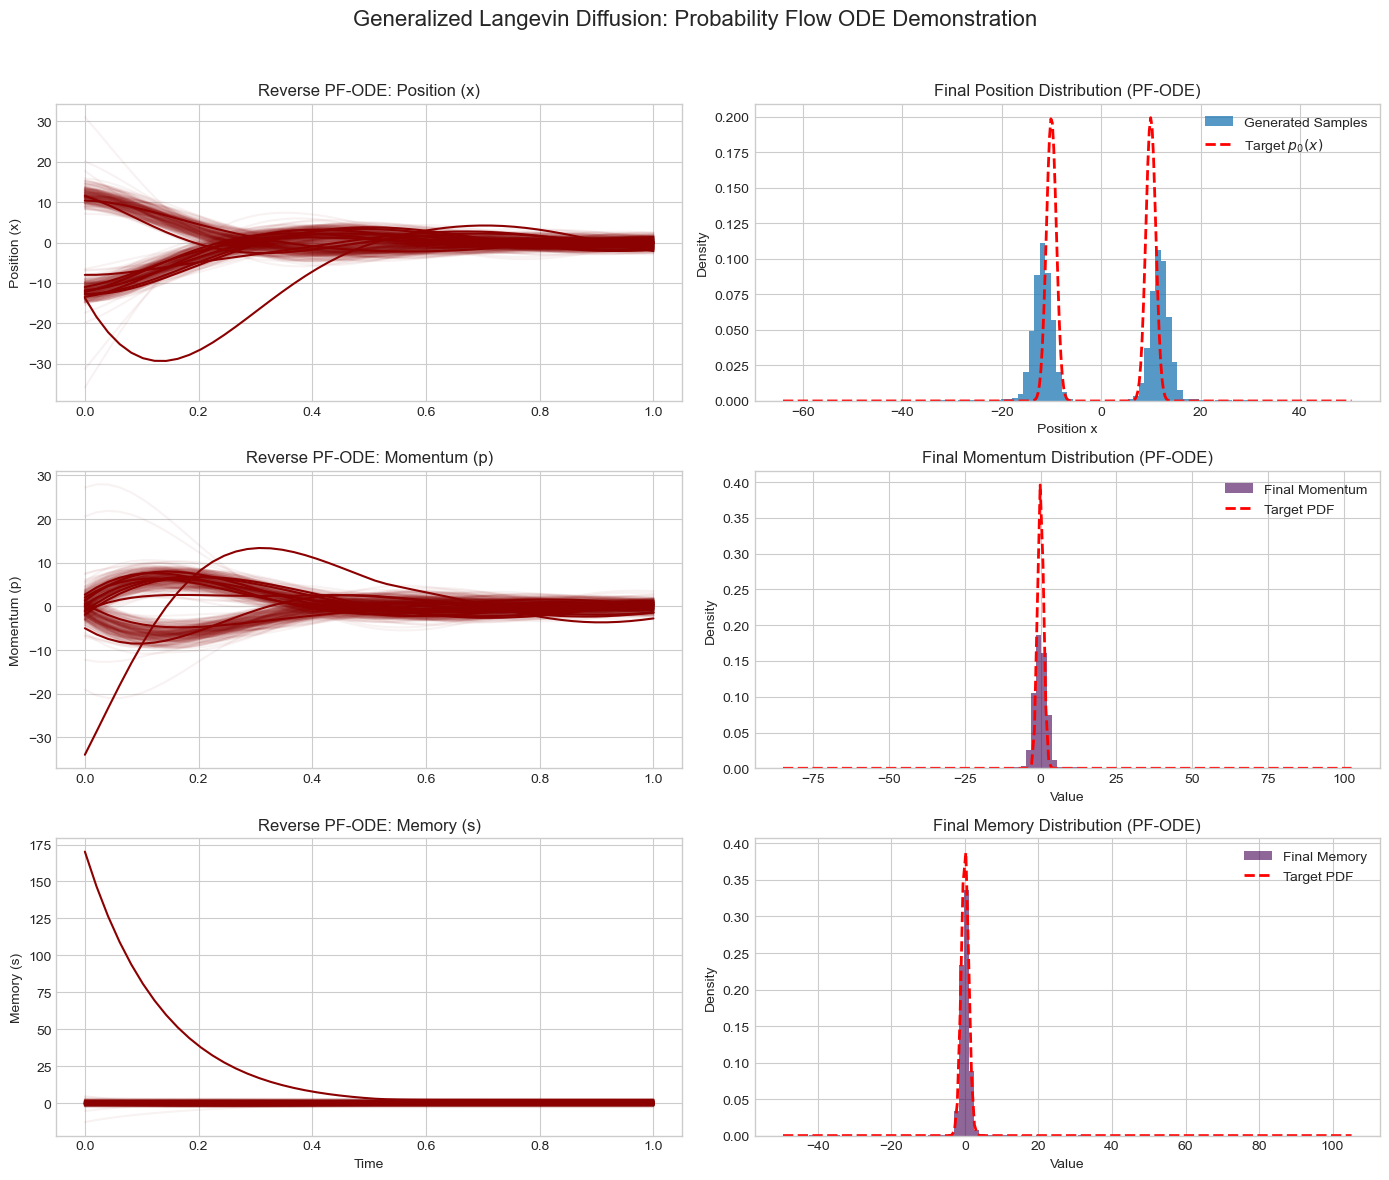

In [2]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-10., 10.],
    'stds': [1., 1.]
}
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'em', gamma=1., lambda_val=1., c_val=0.1, M=1., n_steps=50)
#reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)
pfode_paths = gld_model.run_pfode_demo(n_plot, n_hist)

--- Initializing Generalized Langevin Diffusion ---


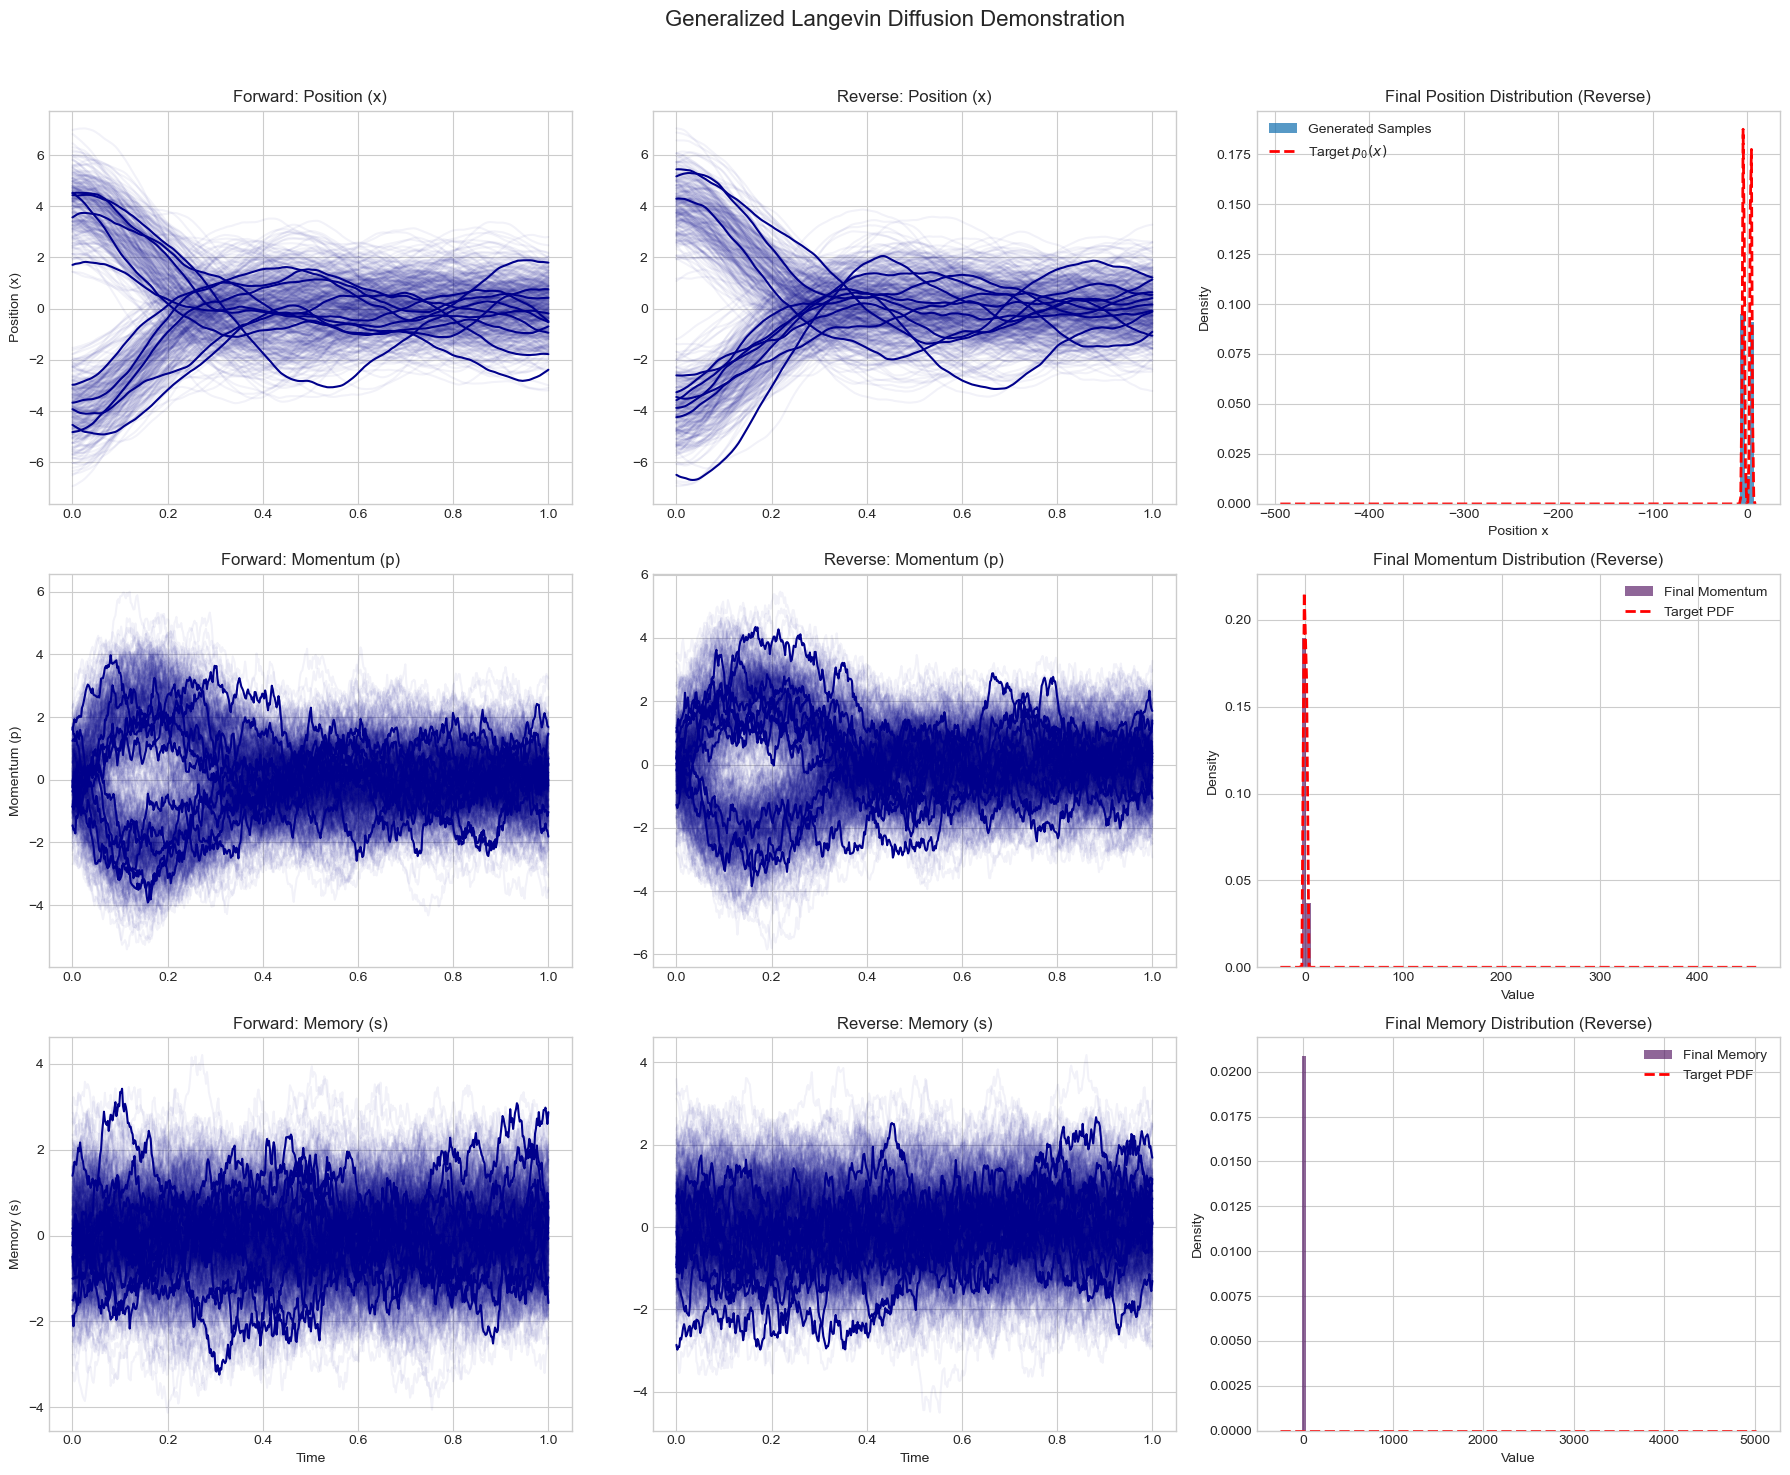

In [2]:
import torch
import numpy as np
import math
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs', gamma=1., lambda_val=1., c_val=0.1, M=1., n_steps=500)
reverse_sde_paths = gld_model.run_demonstration(n_plot, n_hist)


print("A = " ,gld_model.A)
print("B = ", gld_model.B)
print("C = ", gld_model.C_np)
print("F = ", gld_model.F_half_np)
print("S = ", gld_model.S_half_np)
# print("exp_FO_half = ", gld_model.exp_FO_half)
print("dt = ", gld_model.dt)


In [4]:
import torch
import math
from diffusion.cld import CriticallyDampedLangevin
from diffusion.gld import GeneralizedLangevinDiffusion
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-40., 40.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
gld_model = GeneralizedLangevinDiffusion(GMM_PARAMS, inttype= 'sscs2', gamma=2.0, lambda_val=1.0, c_val=0.0, n_steps=1000)


--- Initializing Generalized Langevin Diffusion ---


In [5]:
import scipy.linalg
from matrix_exp import stationary_covariance, compute_mean_and_covariance
scipy.linalg.sqrtm(gld_model.F_half_np)
A_np = gld_model.A.cpu().numpy()
G_np = gld_model.G.cpu().numpy()
C_np = stationary_covariance(gld_model.beta, gld_model.A_np, gld_model.G_np)
print("C_np = ", C_np)
#gld_model.F_half_np

# import scipy.linalg
# A_np = gld_model.A.cpu().numpy()
# G_np = gld_model.G.cpu().numpy()
# dt = gld_model.dt.item()
# F_np = scipy.linalg.expm(-gld_model.beta * A_np * dt/2)
        
# A_np = gld_model.A.numpy()
# dt = gld_model.dt.item()
# beta  = gld_model.beta
# scipy.linalg.expm(-beta * A_np * dt/2)


C_np =  [[ 1.0000001e+00 -6.3517007e-08  0.0000000e+00]
 [-7.9959307e-08  9.9999994e-01  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00]]


--- Initializing Critically Damped Langevin ---


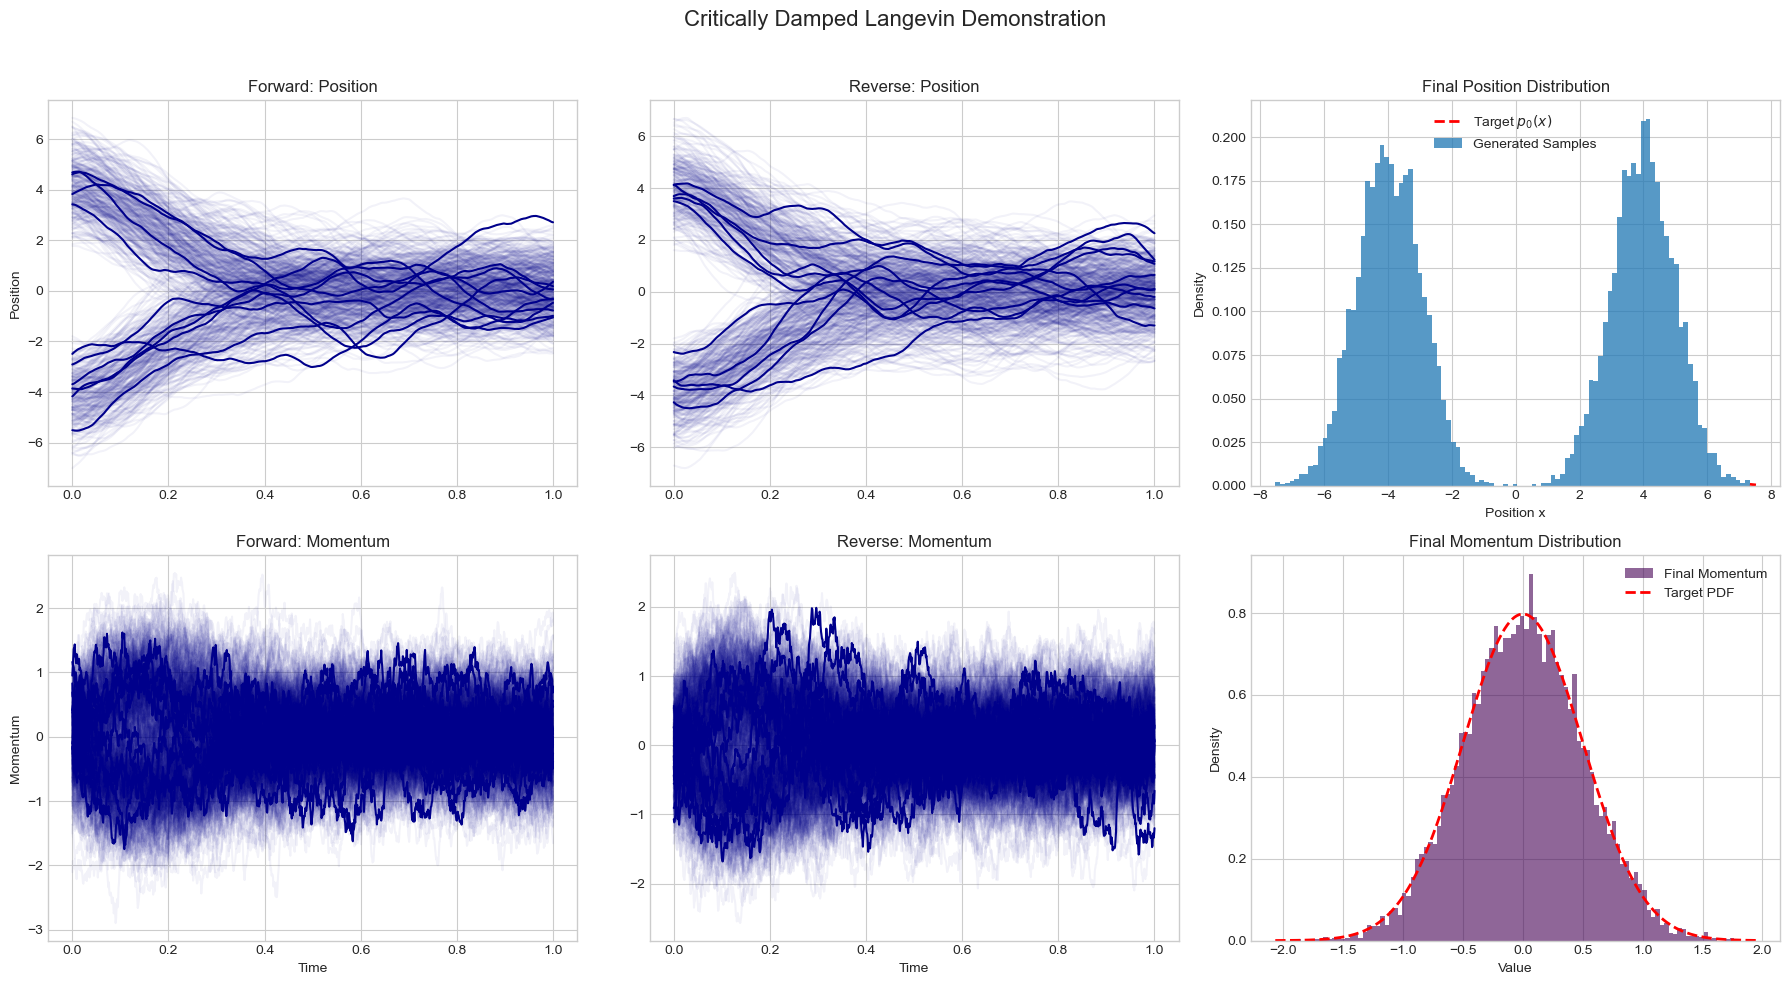

In [6]:
from diffusion.cld import CriticallyDampedLangevin
DEVICE = torch.device("cpu")

GMM_PARAMS = {
    'weights': [0.5, 0.5],
    'means': [-4., 4.],
    'stds': [1., 1.]
}
  # gamma = 1.0
n_plot, n_hist = 500, 10000
cld_model = CriticallyDampedLangevin(GMM_PARAMS, n_steps=1000)
cld_model.run_demonstration(n_plot, n_hist)